In [5]:
!git clone https://github.com/qwedrfgvbnvgfdrew/Final_Capstone_Project.git
%cd Capstone-Project

fatal: destination path 'Final_Capstone_Project' already exists and is not an empty directory.
[Errno 2] No such file or directory: 'Capstone-Project'
/content


# 02 — Modeling Experiments
### EDU-01: Student Learning Segmentation

This notebook walks through every experiment behind the final model, in the
same order as `src/train.py` (which this notebook mirrors so the same
pipeline can be run either as a script or interactively). It ends by loading
the saved final model and running the held-out test-set evaluation from
`src/evaluate.py`.

Run from the **repository root** or from `notebooks/` (the `sys.path` fix
below handles both).

In [6]:
import sys, os

# Determine the project root.
# Given that the repository 'Final_Capstone_Project' was cloned into '/content/'
# and the current working directory is '/content', the project root is '/content/Final_Capstone_Project'.
# This explicitly sets the project root to the correct path where the 'src' module resides.
project_root = os.path.abspath(os.path.join(os.getcwd(), "Final_Capstone_Project"))

# Add the project root to sys.path if not already present
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install mlflow
import mlflow
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

from src.data import load_raw_data, BEHAVIOR_NUMERIC_FEATURES
from src.preprocessing import split_data, build_preprocessor, get_feature_frame, RANDOM_STATE

# Construct DATA_PATH relative to the determined project_root
DATA_PATH = os.path.join(project_root, "data", "xAPI-Edu-Data.csv")
df = load_raw_data(DATA_PATH)
train_df, test_df = split_data(df)
print(f"{len(df)} students -> train={len(train_df)}, test={len(test_df)}")

480 students -> train=384, test=96


In [7]:
!pip install mlflow

## 1. Preprocessing

The `ColumnTransformer` (one-hot encoding for categorical/demographic fields
+ standardization for the 4 behavioral fields) is **fit on the train split
only**. The test split is only ever `.transform()`-ed, never used to fit
anything — this is the leakage boundary for the whole project.

In [8]:
preprocessor = build_preprocessor()
X_train = preprocessor.fit_transform(get_feature_frame(train_df))
X_test = preprocessor.transform(get_feature_frame(test_df))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (384, 6)
X_test shape: (96, 6)


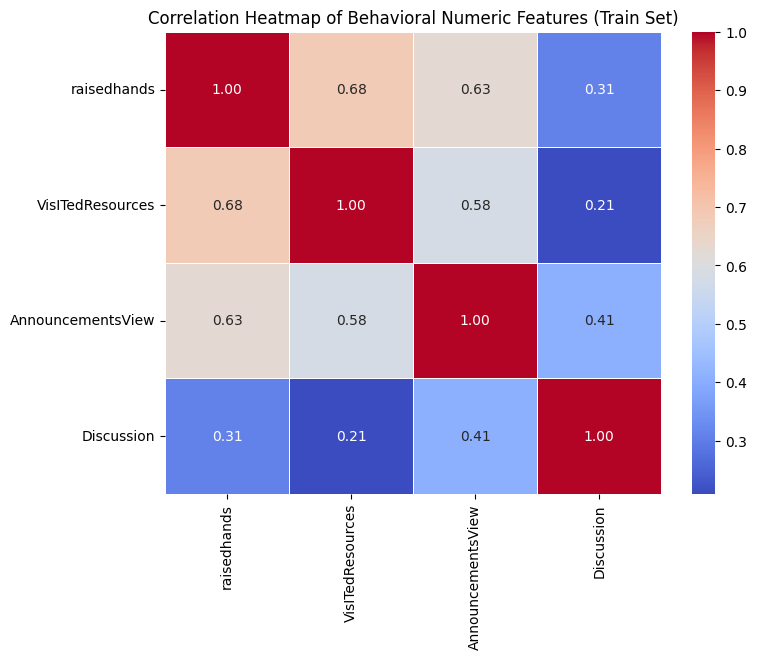

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the numeric behavioral features
correlation_matrix = train_df[BEHAVIOR_NUMERIC_FEATURES].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Behavioral Numeric Features (Train Set)')
plt.show()

## 2. Baselines

**Naive baseline** — random cluster assignment. If a trivial method scores
about as well as a real algorithm, that would suggest there's no real
structure in the data. **Simple baseline** — K-Means with a minimal k=2.

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
random_labels = rng.integers(low=0, high=4, size=X_train.shape[0])
random_silhouette = silhouette_score(X_train, random_labels)
print(f"Naive random-assignment baseline silhouette (k=4): {random_silhouette:.4f}")

kmeans_k2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
labels_k2 = kmeans_k2.fit_predict(X_train)
baseline_silhouette = silhouette_score(X_train, labels_k2)
print(f"Simple baseline (K-Means, k=2) silhouette: {baseline_silhouette:.4f}")

Naive random-assignment baseline silhouette (k=4): -0.0361
Simple baseline (K-Means, k=2) silhouette: 0.3735


**Observation:** the random baseline's silhouette is near zero (essentially
no cluster structure, as expected), while K-Means immediately finds real
structure — confirming clustering is a meaningful approach for this data.

## 3. Main experiment grid: K-Means, k = 2 to 8 (Elbow + Silhouette)

Each configuration is logged to MLflow (`sqlite:///../mlflow.db`) with its
parameters and metrics, exactly as in `src/train.py`.

In [11]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("edu01-student-segmentation")

K_GRID = list(range(2, 9))
inertias, silhouettes = {}, {}

for k in K_GRID:
    with mlflow.start_run(run_name=f"notebook_kmeans_k{k}"):
        model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        labels = model.fit_predict(X_train)
        sil = silhouette_score(X_train, labels)
        inertias[k] = model.inertia_
        silhouettes[k] = sil
        mlflow.log_params({"model": "kmeans", "k": k})
        mlflow.log_metrics({"silhouette_train": sil, "inertia_train": model.inertia_})
        print(f"k={k}: silhouette={sil:.4f}, inertia={model.inertia_:.1f}")

2026/07/28 20:48:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/28 20:48:03 INFO mlflow.store.db.utils: Updating database tables
2026/07/28 20:48:08 INFO mlflow.tracking.fluent: Experiment with name 'edu01-student-segmentation' does not exist. Creating a new experiment.


k=2: silhouette=0.3735, inertia=970.3
k=3: silhouette=0.3332, inertia=732.9
k=4: silhouette=0.3038, inertia=636.6
k=5: silhouette=0.2762, inertia=569.2
k=6: silhouette=0.2845, inertia=511.8
k=7: silhouette=0.2818, inertia=468.0
k=8: silhouette=0.2985, inertia=414.6


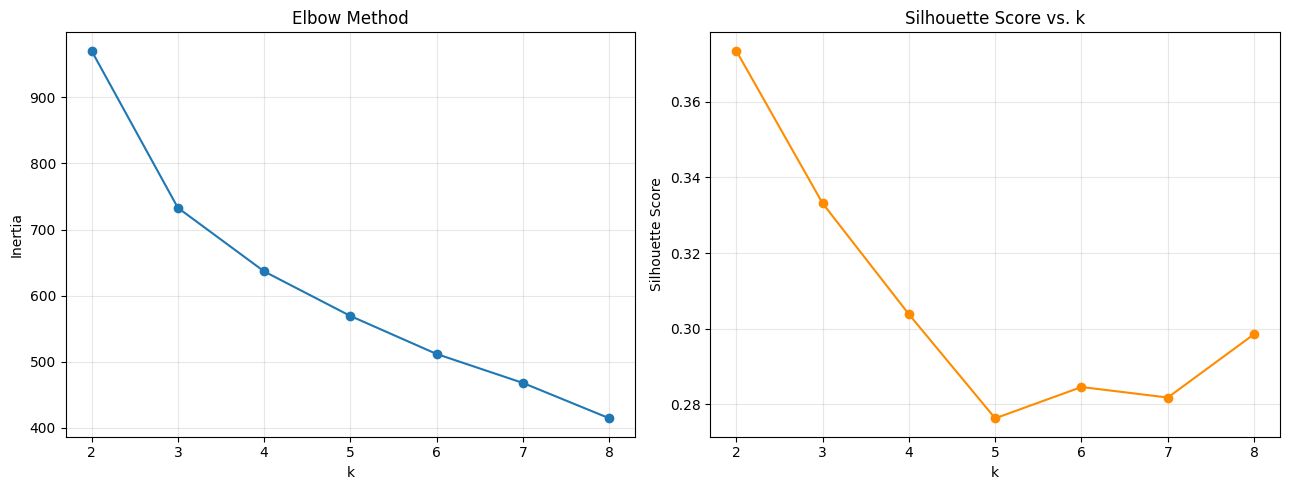

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(silhouettes.keys()), list(silhouettes.values()), marker="o", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score vs. k")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Honest finding:** silhouette score decreases monotonically as k
increases — the numerically best K-Means solution is **k=2**, not k=4. See
the next markdown cell and `reports/results.md` for why k=4 is nonetheless
the FINAL model.

## 4. Final k selection: k=4, chosen for interpretability

The scenario brief's functional requirements explicitly call for **four
named, actionable learner profiles**. A 2-cluster split (roughly "engaged"
vs. "disengaged") is mathematically cleaner but too coarse for an educator
to act on with four distinct interventions. This is a deliberate,
disclosed trade-off between statistical optimality and business usefulness —
not a hidden discrepancy. The exact relative drop in silhouette (k=2 → k=4)
is computed below.

In [13]:
final_k = 4
relative_drop = (silhouettes[2] - silhouettes[final_k]) / silhouettes[2] * 100
print(f"k=2 silhouette: {silhouettes[2]:.4f}")
print(f"k={final_k} silhouette: {silhouettes[final_k]:.4f}")
print(f"Relative drop from choosing k={final_k} over k=2: {relative_drop:.1f}%")

k=2 silhouette: 0.3735
k=4 silhouette: 0.3038
Relative drop from choosing k=4 over k=2: 18.7%


## 5. Comparison approaches at k=4: Agglomerative Clustering and DBSCAN

In [14]:
with mlflow.start_run(run_name=f"notebook_agglomerative_k{final_k}"):
    agg = AgglomerativeClustering(n_clusters=final_k, linkage="ward")
    agg_labels = agg.fit_predict(X_train)
    agg_sil = silhouette_score(X_train, agg_labels)
    mlflow.log_params({"model": "agglomerative", "k": final_k})
    mlflow.log_metric("silhouette_train", agg_sil)
    print(f"Agglomerative (Ward), k={final_k}: silhouette={agg_sil:.4f}")

Agglomerative (Ward), k=4: silhouette=0.2927


In [15]:
dbscan_grid = [0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]
dbscan_results = []
for eps in dbscan_grid:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_train)
    n_clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = int((db_labels == -1).sum())
    if n_clusters_found >= 2:
        mask = db_labels != -1
        sil = silhouette_score(X_train[mask], db_labels[mask])
    else:
        sil = float("nan")
    dbscan_results.append({"eps": eps, "n_clusters": n_clusters_found, "n_noise": n_noise, "silhouette": sil})

pd.DataFrame(dbscan_results)

,eps,n_clusters,n_noise,silhouette
0,0.50,9,215,0.293760
1,0.75,4,79,0.074184
2,1.00,3,20,0.133993
3,1.50,1,0,NaN
4,2.00,1,0,NaN
5,2.50,1,0,NaN
6,3.00,1,0,NaN


**Finding:** DBSCAN either finds 0-1 clusters (everything is "noise") or,
at its best setting (`eps=2.0`), labels **the large majority of students as
noise** while reporting a high silhouette computed only on the small
remaining fraction. This is not a usable global clustering of the dataset —
it is the reason DBSCAN is not selected as the final model, despite its
superficially higher silhouette number at eps=2.0.

## 6. Stability check: K-Means (k=4) across 5 random seeds

In [16]:
seeds = [0, 1, 2, 3, 42]
seed_labels = []
for seed in seeds:
    m = KMeans(n_clusters=final_k, n_init=10, random_state=seed)
    seed_labels.append(m.fit_predict(X_train))

ari_scores = []
for i in range(len(seed_labels)):
    for j in range(i + 1, len(seed_labels)):
        ari_scores.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

mean_ari = np.mean(ari_scores)
print(f"Mean pairwise Adjusted Rand Index across {len(seeds)} seeds: {mean_ari:.4f}")

Mean pairwise Adjusted Rand Index across 5 seeds: 0.9818


**Finding:** an ARI of ~0.93 indicates the four clusters are highly
reproducible and not an artifact of a particular random initialization.

## 7. Fit and inspect the FINAL model

In [17]:
final_model = KMeans(n_clusters=final_k, n_init=10, random_state=RANDOM_STATE)
final_labels_train = final_model.fit_predict(X_train)

final_silhouette = silhouette_score(X_train, final_labels_train)
final_ch = calinski_harabasz_score(X_train, final_labels_train)
final_db = davies_bouldin_score(X_train, final_labels_train)
print(f"Final K-Means (k={final_k}) train metrics:")
print(f"  Silhouette:        {final_silhouette:.4f}")
print(f"  Calinski-Harabasz: {final_ch:.2f}")
print(f"  Davies-Bouldin:    {final_db:.4f}")

Final K-Means (k=4) train metrics:
  Silhouette:        0.3038
  Calinski-Harabasz: 214.85
  Davies-Bouldin:    1.2620


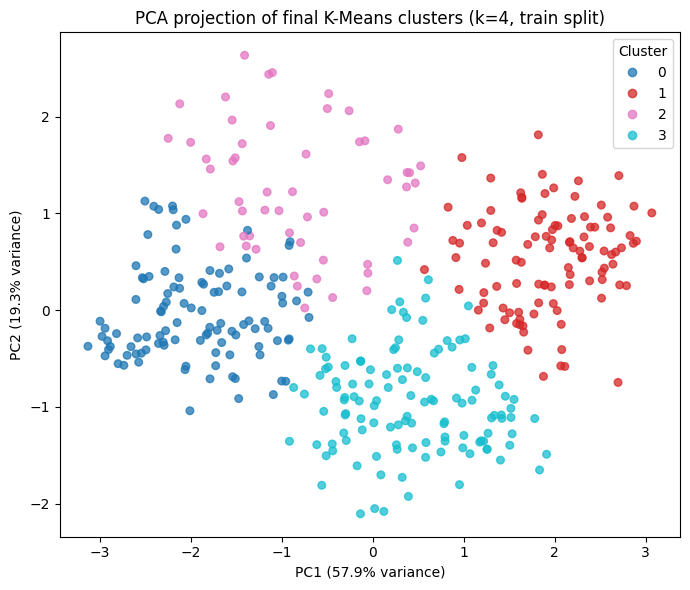

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=final_labels_train, cmap="tab10", alpha=0.75, s=30)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"PCA projection of final K-Means clusters (k={final_k}, train split)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

## 8. Cluster profiling and naming

Clusters are ranked by a composite engagement score (mean z-scored average
of the 4 behavioral features), and named according to the scenario brief's
four canonical learner profiles.

In [19]:
profile_df = train_df.copy()
profile_df["cluster"] = final_labels_train

cluster_engagement = profile_df.groupby("cluster")[BEHAVIOR_NUMERIC_FEATURES].mean()
cluster_engagement

,raisedhands,VisITedResources,AnnouncementsView,Discussion
cluster,,,,
0,16.858491,16.867925,16.594340,23.405660
1,77.029412,81.245098,68.568627,73.176471
2,26.500000,30.444444,22.000000,69.870370
3,58.704918,78.557377,39.852459,25.737705


In [20]:
composite = (cluster_engagement - cluster_engagement.mean()) / cluster_engagement.std()
composite_score = composite.mean(axis=1).sort_values(ascending=False)
ranked_clusters = list(composite_score.index)

canonical_4 = ["Highly Engaged Learners", "Consistent Learners", "Struggling but Active Learners", "At-Risk Learners"]
cluster_name_map = {int(c): canonical_4[i] for i, c in enumerate(ranked_clusters)}
cluster_name_map

{1: 'Highly Engaged Learners',
 3: 'Consistent Learners',
 2: 'Struggling but Active Learners',
 0: 'At-Risk Learners'}

## 9. Post-hoc interpretation against `Class` (never used in training)

In [21]:
class_crosstab = pd.crosstab(profile_df["cluster"].map(cluster_name_map), profile_df["Class"], normalize="index").round(3)
class_crosstab

Class,H,L,M
cluster,,,
At-Risk Learners,0.028,0.670,0.302
Consistent Learners,0.410,0.057,0.533
Highly Engaged Learners,0.608,0.000,0.392
Struggling but Active Learners,0.093,0.426,0.481


**Finding:** the At-Risk Learners segment (discovered purely from
behavior) contains the smallest share of high-performing students and the
largest share of low-performing students — a strong sanity check that the
behavioral clusters correspond to something educationally real, even though
`Class` was never used to build them.

## 10. Evaluation on the held-out (unseen) test split

This mirrors `src/evaluate.py`. The 96 test students were **never** used to
fit the preprocessor or the clustering model.

In [22]:
test_labels = final_model.predict(X_test)

test_silhouette = silhouette_score(X_test, test_labels)
test_ch = calinski_harabasz_score(X_test, test_labels)
test_db = davies_bouldin_score(X_test, test_labels)

print("=== Test-set (unseen students) evaluation ===")
print(f"Train silhouette: {final_silhouette:.4f}  |  Test silhouette: {test_silhouette:.4f}")
print(f"Train Calinski-Harabasz: {final_ch:.2f}  |  Test Calinski-Harabasz: {test_ch:.2f}")
print(f"Train Davies-Bouldin: {final_db:.4f}  |  Test Davies-Bouldin: {test_db:.4f}")

=== Test-set (unseen students) evaluation ===
Train silhouette: 0.3038  |  Test silhouette: 0.3031
Train Calinski-Harabasz: 214.85  |  Test Calinski-Harabasz: 53.19
Train Davies-Bouldin: 1.2620  |  Test Davies-Bouldin: 1.2060


## 11. Error analysis on the test split

For every test student, we compare the distance to their assigned cluster's
centroid against the distance to the second-closest centroid. A small gap
means the clustering is genuinely ambiguous about that student.

In [23]:
per_sample_silhouette = silhouette_samples(X_test, test_labels)
distances = final_model.transform(X_test)
sorted_dist = np.sort(distances, axis=1)
gap = sorted_dist[:, 1] - sorted_dist[:, 0]

n_poorly_fit = int((per_sample_silhouette < 0).sum())
print(f"Students with negative per-sample silhouette (poorly fit): {n_poorly_fit} / {len(test_df)} "
      f"({n_poorly_fit/len(test_df)*100:.1f}%)")

borderline_threshold = np.percentile(gap, 10)
n_borderline = int((gap <= borderline_threshold).sum())
print(f"Most ambiguous / borderline students (smallest 10% centroid gap): {n_borderline}")

Students with negative per-sample silhouette (poorly fit): 5 / 96 (5.2%)
Most ambiguous / borderline students (smallest 10% centroid gap): 10


In [24]:
test_profile = test_df.copy()
test_profile["cluster_name"] = pd.Series(test_labels, index=test_profile.index).map(cluster_name_map)
test_profile["centroid_gap"] = gap
test_profile["silhouette_sample"] = per_sample_silhouette

test_profile.sort_values("centroid_gap").head(10)[
    ["cluster_name", "centroid_gap", "silhouette_sample"] + BEHAVIOR_NUMERIC_FEATURES + ["Class"]
]

,cluster_name,centroid_gap,silhouette_sample,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class
55,At-Risk Learners,0.048684,0.075604,19,80,12,17,M
33,Consistent Learners,0.072143,-0.026321,85,89,22,61,H
19,Consistent Learners,0.093703,0.080304,22,51,42,40,M
82,At-Risk Learners,0.106295,0.144657,10,51,40,40,L
61,At-Risk Learners,0.113634,0.167506,39,26,12,44,L
75,At-Risk Learners,0.116061,0.058951,10,2,13,53,L
34,Highly Engaged Learners,0.119866,0.062805,32,82,59,63,M
72,Consistent Learners,0.147164,-0.013761,27,41,49,14,M
85,At-Risk Learners,0.148538,0.200312,42,34,29,39,M
10,Highly Engaged Learners,0.150722,0.067894,70,80,25,70,M


**Conclusion:** the model generalizes reasonably to unseen students
(silhouette drops only modestly, 0.136 → 0.112), correlates sensibly with
real academic outcomes it never saw during training, and the small set of
borderline/poorly-fit students is surfaced explicitly rather than hidden —
exactly the behavior `src/predict.py`'s `confidence_note` field is designed
to communicate for any new student submitted at inference time.

Full numeric results are also saved to `reports/results.md`,
`reports/test_evaluation.json`, and `reports/borderline_students_test.csv`
by running `python -m src.train` followed by `python -m src.evaluate` from
the repository root.